<a href="https://colab.research.google.com/github/Narges-Sefid/MachineLearning/blob/main/ML_Assignment2_Narges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data

Let's get started with importing and loading the IRIS dataset.

In [1]:
from sklearn.datasets import load_iris

In [2]:
iris=load_iris()

# Exploratory data analysis

##Data count, features, classes and more!

Here we take a look at the dataset which is a relatively small one. It includes 150 samples with 4 features, representing the length and width of sepal and petal for different flowers. These flowers are represented as 3 classes: setosa, versicolor and virginica.

The purpose of this assignment is to train different classification models and compare their accuracy and performance.

In [3]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [6]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [7]:
iris.data.shape

(150, 4)

In [8]:
print("Number of features:", iris.data.shape[1])

Number of features: 4


In [9]:
print("Number of samples:", iris.data.shape[0])

Number of samples: 150


In [10]:
print("Number of classes:",len(iris.target_names))

Number of classes: 3


###Distribution of classes

As we see here, data has 50 samples of each of the three classes. We will come back to this piece later in the "sampling" section.


In [11]:
import numpy as np
unique, counts = np.unique(iris.target, return_counts=True)

In [12]:
counts

array([50, 50, 50])

In [13]:
for class_name, count in zip(iris.target_names, counts):
    print(f"{class_name}: {count}")

setosa: 50
versicolor: 50
virginica: 50


In [14]:
import pandas as pd

In [15]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [17]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df['target'] = iris.target

df['class'] = df['target'].map(lambda x: iris.target_names[x])

print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target   class  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


##Correlations

To catch the relations within the dataset, we look at the correlation between classes and features. To do this, we first drop the 'categorical' target column and only rely on numeric columns.

In [18]:
corr_matrix=df.drop("class", axis=1).corr()

The correlation matrix shows that almost all features(except the sepal length) are highly correlated with the target(class). This piece will also be discussed below in addition to the class distribution piece discussed earlier.

In [19]:
corr_matrix

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


#Stratified sampling

Now is the time to talk about class distribution and feature correlations that we observed before. In the previous assignment, we discovered the high correlation of one feature on the output. So we did a stratified sampling to distribute data evenly between the test and train groups to avoid a gap between train and test data patterns.

In this case, our output is highly correlated with 3 out of 4 features so the idea of stratified sampling based on a feature is not applicable. Therefore, we distribute data between the training and test sets according to classes. Since classes have equal samples(50 each) and the test set is going to be 10% of the data, then our training set will have 45 samples of each class. The following graph shows the distribution of input dataset.

<Axes: >

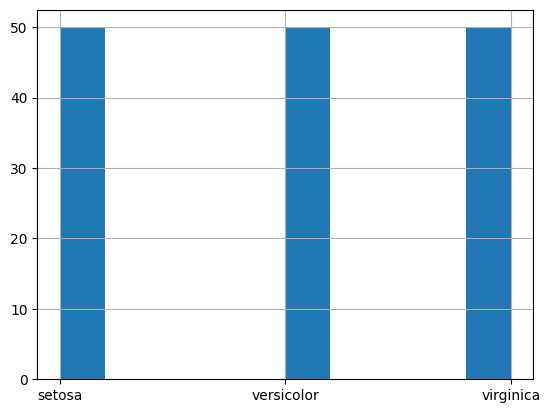

In [20]:
df["class"].hist()

Here we split the dataset into 10% test and 90% training data based on their class distribution.

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=72)
for train_index, test_index in split.split(df, df["class"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]

The following table and graph show the distribution of classes in the test set.

In [22]:
strat_test_set["class"].value_counts() / len(strat_test_set)

,count
class,
virginica,0.333333
versicolor,0.333333
setosa,0.333333


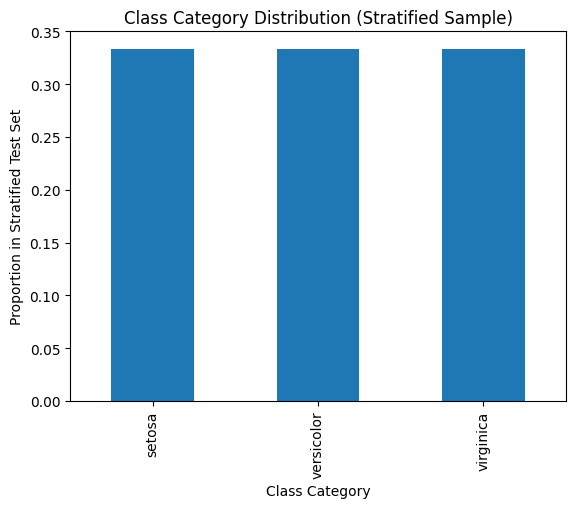

In [23]:
import matplotlib.pyplot as plt
(strat_test_set["class"].value_counts() / len(strat_test_set)).sort_index().plot(kind="bar")
plt.xlabel("Class Category")
plt.ylabel("Proportion in Stratified Test Set")
plt.title("Class Category Distribution (Stratified Sample)")
plt.show()

The test set contains 5 of each class as we see in this table:

In [24]:
strat_test_set

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,class
101,5.8,2.7,5.1,1.9,2,virginica
95,5.7,3.0,4.2,1.2,1,versicolor
145,6.7,3.0,5.2,2.3,2,virginica
37,4.9,3.6,1.4,0.1,0,setosa
10,5.4,3.7,1.5,0.2,0,setosa
125,7.2,3.2,6.0,1.8,2,virginica
46,5.1,3.8,1.6,0.2,0,setosa
24,4.8,3.4,1.9,0.2,0,setosa
19,5.1,3.8,1.5,0.3,0,setosa
50,7.0,3.2,4.7,1.4,1,versicolor


#Training

First we need to prepare a feature set with only numerical data, and a target set, as follows:

For the **training** set:

In [25]:
df_num=strat_train_set.drop("class", axis=1)

In [26]:
labels=strat_train_set["target"].copy()

And for the **testing** set:

In [27]:
test_num=strat_test_set.drop("class", axis=1)

In [28]:
test_labels=strat_test_set["target"].copy()

Then we move on to training 6 different algorithms as follows, and for each we follow these steps:


*   Training with a default hyperparameter value
*   1D grid search to find the best hyperparameter
*   Calculate accuracy for the test set






##Decision Tree classifier



The first algorithm we try for training in this assignment is decision tree classifier. We had tried decision tree regressor in the previous assignment, which was different.

For the **regression** problem, we used **'root mean square error'** as a loss function to determine the algorithm's accuracy. However, **classification** problems have a different nature and require a different accuracy metric. In this assignment, we use the **ratio of correct predictions to the total predictions** as our accuracy criteria.

In addition, we are trying **validation** to find the best value for **hyperparameters** in this assignment. For each algorithm we choose one hyperparameter to play with and apply a** 5 fold cross validation** to find the one with the **best accuracy**.

The following block of code presents the training of the decision tree classifier and its accuracy under different depth values (1 to 10). Please note that **maximum depth of the tree** is our chosen hyperparameter in this case.(**Important note** that in this case we skip discussing the default value since we already discussed it to some extent in the previous assignment)

###Grid search

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

for depth in range(1, 10):
    clf = DecisionTreeClassifier(max_depth=depth)
    scores = cross_val_score(clf, df_num, labels, cv=5)
    print(f"Depth {depth}: Accuracy = {scores.mean():.2f}")

Depth 1: Accuracy = 0.67
Depth 2: Accuracy = 1.00
Depth 3: Accuracy = 1.00
Depth 4: Accuracy = 1.00
Depth 5: Accuracy = 1.00
Depth 6: Accuracy = 1.00
Depth 7: Accuracy = 1.00
Depth 8: Accuracy = 1.00
Depth 9: Accuracy = 1.00


The above results for different max depth values and their corresponding accuracy show that max depth = 1 does not have the best accuracy (0.67 < 1) however max depth = 2 gives a perfect accuracy of 1.

What we don't know here is whether this is a perfectly trained model or an overfitted one. To find out, we need to try this on the testing set and see how it performs.

###Test set evaluation

In [30]:
for depth in range(1, 10):
    clf = DecisionTreeClassifier(max_depth=depth)
    scores = cross_val_score(clf, test_num, test_labels, cv=5)
    print(f"Depth {depth}: Accuracy = {scores.mean():.2f}")

Depth 1: Accuracy = 0.60
Depth 2: Accuracy = 1.00
Depth 3: Accuracy = 1.00
Depth 4: Accuracy = 0.93
Depth 5: Accuracy = 1.00
Depth 6: Accuracy = 0.93
Depth 7: Accuracy = 1.00
Depth 8: Accuracy = 0.93
Depth 9: Accuracy = 0.87


Above results from our test set evaluation show that the accuracy of the test set for max depth = 2 is 1, which shows that the model trained with this hyperparameter value is not overfitted. Therefore max depth = 2 is our best hyperparameter value.

The IRIS dataset is a small, clean and simple dataset, so it makes total sense that a tree with 2 layer depth can capture the 3 classes(a tree of depth 1 can capture 2 classes since it has 2 branches).

Given that the dataset is small, we print the prediction values for the test evaluation under 3 different depth values(1, 2 and 6) to see how accurate are the predicted values.

In [31]:
clf = DecisionTreeClassifier(max_depth=1)

In [32]:
clf.fit(df_num, labels)

DecisionTreeClassifier(max_depth=1)

In [33]:
print("Predictions(Underfitted model):", clf.predict(test_num))

Predictions(Underfitted model): [1 1 1 0 0 1 0 0 0 1 1 1 1 1 1]


In [34]:
clf = DecisionTreeClassifier(max_depth=2)

In [35]:
clf.fit(test_num, test_labels)

DecisionTreeClassifier(max_depth=2)

In [36]:
print("Predictions(Best model):", clf.predict(test_num))

Predictions(Best model): [2 1 2 0 0 2 0 0 0 1 1 2 2 1 1]


In [37]:
print("Labels:", list(test_labels))

Labels: [2, 1, 2, 0, 0, 2, 0, 0, 0, 1, 1, 2, 2, 1, 1]


In [38]:
clf = DecisionTreeClassifier(max_depth=6)

In [39]:
clf.fit(test_num, test_labels)

DecisionTreeClassifier(max_depth=6)

In [40]:
print("Predictions(Overfitted model):", clf.predict(test_num))

Predictions(Overfitted model): [2 1 2 0 0 2 0 0 0 1 1 2 2 1 1]


From these printed prediction values we find out that depth 1 is too simple and can nor distinguish class 2 samples, and depths higher than 2 are too complex an dunnecessary for solving this problem.

#Training other models

Here we also train 5 more models with the following algorithms:

*   Randon Forest
*   K Nearest Neighbor
*   Perceptron
*   Support Vector Machine
*   Adaboot







##Random Forest

###Default hyperparameter value

In this case our hyperparameter is **'number of estimators'** and it's default value is 100.




In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [42]:
RandomForest = RandomForestClassifier(n_estimators=100, random_state=72)
RandomForest.fit(df_num, labels)

RandomForestClassifier(random_state=72)

In [43]:
Predict_RF = RandomForest.predict(test_num)
print("Predictions(Random Forest):", Predict_RF)

Predictions(Random Forest): [2 1 2 0 0 2 0 0 0 1 1 2 2 1 1]


In [44]:
print("Accuracy:", accuracy_score(test_labels, Predict_RF))
print("\nClassification Report:\n", classification_report(test_labels, Predict_RF, target_names=iris.target_names))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         5
   virginica       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



###Grid search


Eventhough the default value worked and performed perfect accuracy of 1 for both train and test samples, here we try a range of values for this hyperparameter to find the best value and train a more robust model.

In [45]:
estimator_values = [1, 5, 10, 20, 50, 100, 200, 300]
cv_scores = []

In [46]:
for n in estimator_values:
    clf = RandomForestClassifier(n_estimators=n, random_state=72)
    scores = cross_val_score(clf, df_num, labels, cv=5)
    mean_score = scores.mean()
    cv_scores.append(mean_score)
    print(f"n_estimators = {n}: Average CV Accuracy = {mean_score:.4f}")

n_estimators = 1: Average CV Accuracy = 0.9852
n_estimators = 5: Average CV Accuracy = 1.0000
n_estimators = 10: Average CV Accuracy = 1.0000
n_estimators = 20: Average CV Accuracy = 1.0000
n_estimators = 50: Average CV Accuracy = 1.0000
n_estimators = 100: Average CV Accuracy = 1.0000
n_estimators = 200: Average CV Accuracy = 1.0000
n_estimators = 300: Average CV Accuracy = 1.0000


###Test set evaluation

Results of our grid search indicate that the lowest hyperparameter value that gives an accuracy of 1 is 5. However, we don't know if it is an overfitting and need to try it on the test set to make sure.

In [47]:
RandomForest = RandomForestClassifier(n_estimators=5, random_state=72)
RandomForest.fit(df_num, labels)

RandomForestClassifier(n_estimators=5, random_state=72)

In [48]:
Predict_RF = RandomForest.predict(test_num)
print("Predictions(Random Forest):", Predict_RF)

Predictions(Random Forest): [2 1 2 0 0 2 0 0 0 1 1 2 2 1 1]


In [49]:
print("Accuracy:", accuracy_score(test_labels, Predict_RF))
print("\nClassification Report:\n", classification_report(test_labels, Predict_RF, target_names=iris.target_names))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         5
   virginica       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



The test accuracy was 1 as well wich means the model was properly trained and is not overfitting.

##KNN

In [50]:
from sklearn.neighbors import KNeighborsClassifier

###Default hyperparameter value

For this algorithm, **number of neighbors** is the hyperparameter and its default value is 3. Let's try it:

In [110]:
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7))
knn.fit(df_num, labels)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=7))])

In [111]:
Predict_KNN = knn.predict(test_num)
print("Predictions(K Nearest Neighbor):", Predict_KNN)

Predictions(K Nearest Neighbor): [2 1 2 0 0 2 0 0 0 1 1 2 2 1 1]


In [112]:
print("Accuracy:", accuracy_score(test_labels, Predict_KNN))
print("\nClassification Report:\n", classification_report(test_labels, Predict_KNN, target_names=iris.target_names))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         5
   virginica       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



###Grid search

According to the 5 fold cross validation below, for k=10 the model is not accurate enough, and for lower values it gives a full accuracy. So we ned to check the overfitting state.

In [113]:
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, df_num, labels, cv=5)
    print(f"k={k}, mean accuracy = {scores.mean():.4f}")


k=1, mean accuracy = 1.0000
k=2, mean accuracy = 1.0000
k=3, mean accuracy = 1.0000
k=4, mean accuracy = 1.0000
k=5, mean accuracy = 1.0000
k=6, mean accuracy = 1.0000
k=7, mean accuracy = 1.0000
k=8, mean accuracy = 1.0000
k=9, mean accuracy = 1.0000
k=10, mean accuracy = 0.9926


###Test set evaluation

k = 9 is the highest k value with accuracy of 1, so if its accuracy for test set is 1 as well, we can conclude that it's the best number of neighbors. The following blocks admit our conclusion.

Important note that eventhough in the previous algorithms, the lowest hyperparameter value with accuracy of one was chosen as the best, in this case, the highest number of neighbors with this conditions is our desired value.

In [114]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(df_num, labels)

KNeighborsClassifier(n_neighbors=9)

In [115]:
Predict_KNN = knn.predict(test_num)
print("Predictions(K Nearest Neighbor):", Predict_KNN)

Predictions(K Nearest Neighbor): [2 1 2 0 0 2 0 0 0 1 1 2 2 1 1]


In [116]:
print("Accuracy:", accuracy_score(test_labels, Predict_KNN))
print("\nClassification Report:\n", classification_report(test_labels, Predict_KNN, target_names=iris.target_names))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         5
   virginica       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



##Perceptron

In [64]:
from sklearn.linear_model import Perceptron

In this case we need to scale the features, eventhough they have the same unit, their ranges vary and it may bias the results as the feature with the largest range can dominate the learning.

In [65]:
from sklearn.preprocessing import StandardScaler

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_num)
X_test_scaled = scaler.transform(test_num)

###Default hyperparameter value

Eventhough this algorithm has more than one hyperparameters, for instance **maximum iterations** or **error tolerance**, we chose error tolerance as our target hyperparameter. So we used the default value of 1e-3 for error tolerance, and 1000 for max iterations.

In [67]:
Percept = Perceptron(max_iter=1000, tol=1e-3, random_state=72)
Percept.fit(X_train_scaled, labels)

Perceptron(random_state=72)

In [68]:
Prediction_P = Percept.predict(X_train_scaled)

print("Accuracy:", accuracy_score(labels, Prediction_P))
print("\nClassification Report:\n", classification_report(labels, Prediction_P, target_names=iris.target_names))

Accuracy: 0.9703703703703703

Classification Report:
               precision    recall  f1-score   support

      setosa       0.94      0.98      0.96        45
  versicolor       0.98      0.93      0.95        45
   virginica       1.00      1.00      1.00        45

    accuracy                           0.97       135
   macro avg       0.97      0.97      0.97       135
weighted avg       0.97      0.97      0.97       135



The accuracy is 0.97 and shows that eventhough this algorithm gives a high performance but is not better than other algorithms.

###Grid search

For our grid search we first do a 5 fold on max iteration as follows:

In [84]:
max_iter_values = [10, 50, 100, 500, 1000, 2000]

for max_iter in max_iter_values:
    Percept = Perceptron(max_iter=max_iter, tol=1e-3, random_state=72)
    scores = cross_val_score(Percept, X_train_scaled, labels, cv=5)
    print(f"max_iter={max_iter}: mean accuracy = {np.mean(scores):.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


max_iter=10: mean accuracy = 0.9407
max_iter=50: mean accuracy = 0.9556
max_iter=100: mean accuracy = 0.9556
max_iter=500: mean accuracy = 0.9556
max_iter=1000: mean accuracy = 0.9556
max_iter=2000: mean accuracy = 0.9556


Then we look at the actual number of iterations and realize the algorithm only goes through 8 iterations no matter the max iteration.

In [83]:
for max_iter in [10, 50, 100, 500, 1000, 2000]:
    Percept = Perceptron(max_iter=max_iter, tol=1e-3, random_state=72)
    Percept.fit(X_train_scaled, labels)
    acc = accuracy_score(test_labels, Percept.predict(X_test_scaled))
    print(f"max_iter={max_iter}: accuracy={acc:.4f} - Actual number of iterations used:", Percept.n_iter_)

max_iter=10: accuracy=0.8667 - Actual number of iterations used: 8
max_iter=50: accuracy=0.8667 - Actual number of iterations used: 8
max_iter=100: accuracy=0.8667 - Actual number of iterations used: 8
max_iter=500: accuracy=0.8667 - Actual number of iterations used: 8
max_iter=1000: accuracy=0.8667 - Actual number of iterations used: 8
max_iter=2000: accuracy=0.8667 - Actual number of iterations used: 8


In [76]:
Prediction_P = Percept.predict(X_test_scaled)

print("Accuracy:", accuracy_score(test_labels, Prediction_P))
print("\nClassification Report:\n", classification_report(test_labels, Prediction_P, target_names=iris.target_names))

Accuracy: 0.8666666666666667

Classification Report:
               precision    recall  f1-score   support

      setosa       0.83      1.00      0.91         5
  versicolor       1.00      0.60      0.75         5
   virginica       0.83      1.00      0.91         5

    accuracy                           0.87        15
   macro avg       0.89      0.87      0.86        15
weighted avg       0.89      0.87      0.86        15



So next we apply another 5 fold cross validation on the error tolerance. Results are nopt much different than previous grid search.

In [77]:
for tol in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    Percept = Perceptron(tol=tol, max_iter=1000, random_state=72)
    scores = cross_val_score(Percept, X_train_scaled, labels, cv=5)
    print(f"tol={tol:.0e}: mean accuracy = {scores.mean():.4f}")

tol=1e-01: mean accuracy = 0.9704
tol=1e-02: mean accuracy = 0.9556
tol=1e-03: mean accuracy = 0.9556
tol=1e-04: mean accuracy = 0.9556
tol=1e-05: mean accuracy = 0.9556


###Test set evaluation

Eventualy we train the model for 10 max iterations and default tolerance and calculate accuracy.

In [117]:
Percept = Perceptron(max_iter=50, tol=1e-3, random_state=72)
Percept.fit(X_train_scaled, labels)

Perceptron(max_iter=50, random_state=72)

In [118]:
Prediction_P = Percept.predict(X_test_scaled)

print("Accuracy:", accuracy_score(test_labels, Prediction_P))
print("\nClassification Report:\n", classification_report(test_labels, Prediction_P, target_names=iris.target_names))

Accuracy: 0.8666666666666667

Classification Report:
               precision    recall  f1-score   support

      setosa       0.83      1.00      0.91         5
  versicolor       1.00      0.60      0.75         5
   virginica       0.83      1.00      0.91         5

    accuracy                           0.87        15
   macro avg       0.89      0.87      0.86        15
weighted avg       0.89      0.87      0.86        15



From this experience, we conclude that Perceptron is not the best algorithm for the iris dataset, since it is a linear classifier.

##Support Vector Machine

In [87]:
from sklearn.svm import SVC

In [88]:
from sklearn.pipeline import make_pipeline

In [89]:
svm_clf = make_pipeline(StandardScaler(), SVC())

###Default hyperparameter value

In this case, the hyperparameter is the **regularization parameter(C)** and its default value is 1.

In [90]:
svm_clf.fit(df_num, labels)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])

Default value's trained model shows an accuracy of 1 for training and test samples, meaning that it is working well.

In [91]:
test_accuracy = svm_clf.score(test_num, test_labels)
print(f"Test set accuracy: {test_accuracy:.3f}")

Test set accuracy: 1.000


###Grid search

But let's try some other C values and see if they work better.

In [92]:
C_values = [0.01, 0.1, 1, 10, 100]
best_score = 0
best_C = None

In [93]:
for C in C_values:
    svm_clf = SVC(C=C)
    scores = cross_val_score(svm_clf, df_num, labels, cv=5)
    mean_score = np.mean(scores)
    print(f"C={C}: Cross-validated accuracy = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_C = C

C=0.01: Cross-validated accuracy = 0.9926
C=0.1: Cross-validated accuracy = 0.9926
C=1: Cross-validated accuracy = 1.0000
C=10: Cross-validated accuracy = 1.0000
C=100: Cross-validated accuracy = 1.0000


In [94]:
print(f"\nBest C: {best_C} with accuracy: {best_score:.4f}")


Best C: 1 with accuracy: 1.0000


###Test set evaluation

Since the best C value was the default value of 1, we try it on the test sample to see its accuracy.

In [95]:
svm_clf = make_pipeline(StandardScaler(), SVC())

In [96]:
svm_clf.fit(df_num, labels)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])

In [97]:
Prediction_SVM = svm_clf.predict(test_num)

In [98]:
accuracy = accuracy_score(test_labels, Prediction_SVM)
print(f"Test set accuracy with C=1: {accuracy:.4f}")

Test set accuracy with C=1: 1.0000


##Adaboost

In [99]:
from sklearn.ensemble import AdaBoostClassifier

###Default hyperparameter value

Adaboost is an algorithm that combines multiple weak classifiers, in this case decision tree.

In [100]:
base = DecisionTreeClassifier(max_depth=1)

The hyperparameter for Adaboost is the **number of estimators**, which in this case is the number of trees and is equal to 3.

In [101]:
ada = AdaBoostClassifier(estimator=base, n_estimators=3, learning_rate=1.0)

In [102]:
ada.fit(df_num, labels)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=3)

In [103]:
Predictions_ada = ada.predict(test_num)

In [104]:
accuracy = accuracy_score(test_labels, Predictions_ada)
print(f"AdaBoost test set accuracy: {accuracy:.4f}")

AdaBoost test set accuracy: 1.0000


###Grid search

In [105]:
param_grid = [1, 2, 3, 5]

In [106]:
for n in param_grid:
    clf = AdaBoostClassifier(estimator=base, n_estimators=n, random_state=72)
    scores = cross_val_score(clf, df_num, labels, cv=5)
    print(f"n_estimators = {n}: Cross-validated accuracy = {np.mean(scores):.4f}")

n_estimators = 1: Cross-validated accuracy = 0.6667
n_estimators = 2: Cross-validated accuracy = 0.6667
n_estimators = 3: Cross-validated accuracy = 1.0000
n_estimators = 5: Cross-validated accuracy = 1.0000


Grid search and cross-validation show that 3 is the best number of estimators. So the test set evaluation is same as above.

#Comparison/concolusion

| Model           | Linear/Non-linear         | Binary/Multiclass             | OvO / OvR                       | Scaling Sensitive? | Hyperparameter               | Best value | Accuracy |
|-----------------|---------------------------|-------------------------------|--------------------------------|-------------------|-----------------------------|------------|----------|
| Decision Tree   | Non-linear                | Native multiclass             | N/A (native multiclass)         | No                | Depth                      | 2          | 1.00     |
| Random Forest   | Non-linear                | Native multiclass             | N/A                            | No                | Number of trees            | 5          | 1.00     |
| KNN             | Non-linear                | Native multiclass             | N/A                            | Yes               | Number of neighbors        | 9          | 1.00     |
| Perceptron      | Linear                    | Binary (needs OvR)            | OvR                            | Yes               | Error tolerance            | 1e-2       | 0.87     |
| SVM             | Linear or Non-linear      | Binary (needs OvO or OvR)     | OvO (default), OvR (optional)  | Yes               | Regularization parameter (C)| 1         | 1.00     |
| AdaBoost        | Non-linear (base-dependent)| Usually binary (extendable)  | OvR (when extended)             | No (usually)       | Number of estimators       | 3          | 1.00     |
